https://drive.google.com/file/d/11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe/view?usp=sharing --- тут лежит датасет который мы будем использовать. \
Мы хотим обучить наш unet на небольшом датасете. Нужно заполнить репорт и сделать выводы. Чтобы успеть сделать много экспериментов нужна видеокарта. Можно использовать colab, тут есть бесплатные gpu ресурсы --- так будет быстрее.

  * Сделать train/test split (или кросс-валидацию), зафиксировать все сиды, чтобы более-менее воспроизводились результаты. Добавить метрику jaccard index. Переобучиться на одном батче (например, 4 картинки), попробовать получить почти идеальное качество, посмотреть, получилось или нет. Посчитать метрики для батча и для теста. Обучить на всем train, построить train/val кривые для loss и для jaccard index, подобрать оптимальное время обучения (количество шагов) для фиксированных параметров. Визуализировать topN самых плохих предсказаний.
  * Попробовать улучшить качество не меняя архитектуру: аугментации, гиперпараметры. Сделать test time аугментации через horizontal flip, посмотреть улучшается ли что-то.
  * Попробовать улучшить качество изменяя архитектуру.
 * (+2 балла) Сделать train/test разбиение. Внутри train сделать 5fold, обучить 5 моделей. Построить кривые обучения для каждого фолда. Предсказать тест со всех 5 моделей и сагрегировать предсказания (до расчета метрик), сравнить с одной моделью обученной на всех данных. Сравнить с моделями обученными на фолдах. Сравнить плохие предсказания теста на разных фолдах. Ошибается на одних и тех же семплах или на разных?
 * (+3 балла) Сделать unet с pretrained энкодером (можно взять vgg или resnet18/34), сравнить с предыдущими пунктами.

In [2]:
device = "cuda"

In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


##Датасет

In [4]:
!pip install -q gdown

In [5]:
!gdown 11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe -O dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe
From (redirected): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe&confirm=t&uuid=bc1f3d0a-a263-4307-a501-cf674bb9eee1
To: /content/dataset.zip
100% 154M/154M [00:03<00:00, 44.8MB/s]


In [6]:
!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
   creating: /content/dataset/dataset/
   creating: /content/dataset/dataset/masks/
  inflating: /content/dataset/dataset/masks/1803262049-00000501.png  
  inflating: /content/dataset/dataset/masks/1803280840-00000089.png  
  inflating: /content/dataset/dataset/masks/1803242348-00000392.png  
  inflating: /content/dataset/dataset/masks/1803251131-00000060.png  
  inflating: /content/dataset/dataset/masks/1803240928-00000328.png  
  inflating: /content/dataset/dataset/masks/1803260459-00000293.png  
  inflating: /content/dataset/dataset/masks/1803271238-00000380.png  
  inflating: /content/dataset/dataset/masks/1803280628-00000458.png  
  inflating: /content/dataset/dataset/masks/1803280908-00000324.png  
  inflating: /content/dataset/dataset/masks/1803260434-00000062.png  
  inflating: /content/dataset/dataset/masks/1803241125-00000172.png  
  inflating: /content/dataset/dataset/masks/1803191139-00000845.png  
  inflating: /content/dataset/dataset/masks/1803260434

In [7]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)
    print(files[:5])
    print('---')

/content/dataset
[]
---
/content/dataset/dataset
[]
---
/content/dataset/dataset/masks
['1803271743-00000327.png', '1803260054-00000076.png', '1803290444-00000528.png', '1803262023-00000569.png', '1803250018-00000427.png']
---
/content/dataset/dataset/images
['1803280908-00000049.jpg', '1803242010-00000066.jpg', '1803250018-00000113.jpg', '1803261336-00000041.jpg', '1803252014-00000510.jpg']
---


In [24]:
import os
import random
import numpy as np
from glob import glob

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.transforms import functional
from torchvision import io
import torchvision.transforms as transforms
from torch import nn


###Фиксируем сиды

In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
image_paths = sorted(glob('/content/dataset/dataset/images/*'))
mask_paths = sorted(glob('/content/dataset/dataset/masks/*'))

print(len(image_paths))
print(len(mask_paths))

2000
2000


###Проверяем картинку и маску

(800, 600, 3)
(800, 600)


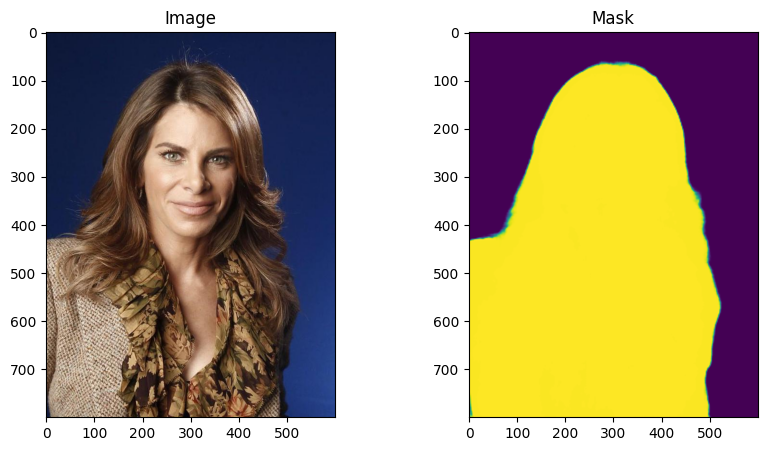

In [11]:
idx = 0

image = cv2.imread(image_paths[idx])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_paths[idx], 0)

print(image.shape)
print(mask.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Image')

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Mask')

plt.show()

In [12]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=SEED
)

print('Train:', len(train_imgs))
print('Val:', len(val_imgs))

Train: 1600
Val: 400


In [20]:
image_prepare = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks, transform=image_prepare):
        self.images = images
        self.masks = masks

        assert len(self.images) == len(self.masks)

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, item):
        img = self.transform(io.read_image(str(self.images[item])))
        mask = self.transform(io.read_image(str(self.masks[item])))
        return img, mask

In [22]:
train_dataset = SegmentationDataset(
    train_imgs,
    train_masks
)

val_dataset = SegmentationDataset(
    val_imgs,
    val_masks
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8
)

In [23]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 3, 800, 600])
torch.Size([8, 1, 800, 600])


###Построение UNET

In [26]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(CNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.seq_block(x)

class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
          super(CNNBlocks, self).__init__()

          self.layers = nn.ModuleList()
          for _ in range(n_conv):
              self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
              in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()

        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [CNNBlocks(n_conv=2,
                                          in_channels=in_channels,
                                          out_channels=out_channels,
                                          padding=padding),
                                nn.MaxPool2d(2, 2)
                                ]

            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(CNNBlocks(n_conv=2,
                                         in_channels=in_channels,
                                         out_channels=out_channels,
                                         padding=padding
                                         ))

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                            CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding)]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0))

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x

class UNET(nn.Module):
    def __init__(self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1):
        super(UNET, self).__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(first_out_channels * (2 ** n_down),
                               first_out_channels * (2 ** (n_down - 1)),
                               exit_channels, padding=padding, n_up=n_down)

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)